In [38]:
!pip install matplotlib

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

In [40]:
def plot_grid_world(start_state, current_state, goal_state, obstacles, path):
    """Displays a grid world environment with agent's path, obstacles, and goal."""

    # Define grid dimensions
    grid_height, grid_width = 6, 6
    grid = np.zeros((grid_height, grid_width))  # Initialize grid with zeros

    # Set obstacle locations in the grid
    for obs in obstacles:
        grid[obs] = -1  # Mark obstacles

    # Place goal state in the grid
    grid[goal_state] = 1

    # Mark the agent's path
    for idx, step in enumerate(path):
        if step != goal_state:  # Avoid overwriting goal marker
            grid[step] = 0.5 + (idx / len(path)) * 0.5  # Progressively darken path

    # Visualize grid with 'viridis' color map
    plt.imshow(grid, cmap='viridis', origin='upper')
    plt.colorbar(label='State Values')

    # Highlight start and current state
    plt.scatter(start_state[1], start_state[0], marker='o', color='blue', s=100, label='Start')
    plt.scatter(current_state[1], current_state[0], marker='x', color='red', s=100, label='Current Position')

    # Add labels and title
    plt.title('Grid World Visualization')
    plt.xlabel('Column Index')
    plt.ylabel('Row Index')
    plt.xticks(np.arange(grid_width))
    plt.yticks(np.arange(grid_height))
    plt.legend()
    plt.show()


In [41]:
# Define the Q-network model
class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(QNetwork, self).__init__()
        # Define the layers
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 64)
        self.output_layer = nn.Linear(64, output_dim)

    def forward(self, x):
        # Apply ReLU activation to each hidden layer
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        # Output layer
        return self.output_layer(x)

In [42]:
# Hyperparameters
gamma = 0.9
epsilon = 0.1
alpha = 0.001  # Learning rate
episodes = 50
batch_size = 32
memory_size = 1000

In [43]:
# Initialize the neural network, optimizer, and loss function
input_dim = 2  # Dimensions for state (e.g., row, col)
output_dim = 4  # Number of possible actions: up, down, left, right

# Instantiate the Q-network
q_network = QNetwork(input_dim=input_dim, output_dim=output_dim)

# Set up the optimizer and loss function
learning_rate = alpha  # Define `alpha` beforehand as the learning rate
optimizer = optim.Adam(q_network.parameters(), lr=learning_rate)
loss_function = nn.MSELoss()  # Mean squared error for Q-learning updates

In [44]:
# Replay buffer
replay_buffer = deque(maxlen=1000)
batch_size = 32

In [45]:
# Define the environment parameters
grid_height, grid_width = 6, 6  # Dimensions of the grid
start_state = (0, 0)            # Starting position of the agent
goal_state = (5, 5)             # Goal position for the agent
obstacles = [(1, 1), (2, 2), (3, 4)]  # Positions of obstacles in the grid

# Define possible actions and corresponding movement mappings
actions = ['up', 'down', 'left', 'right']
action_map = {
    'up': (-1, 0),     # Move up by decreasing row index
    'down': (1, 0),    # Move down by increasing row index
    'left': (0, -1),   # Move left by decreasing column index
    'right': (0, 1)    # Move right by increasing column index
}


In [46]:
# Track metrics
steps_per_episode = []
rewards_per_episode = []
penalties_per_episode = []

In [47]:
def choose_action(state):
    """Selects an action for the agent based on the epsilon-greedy policy.

    Args:
        state (tuple): The current state of the agent, typically (row, col) in the grid.

    Returns:
        int: Index of the chosen action (0 to output_dim - 1).
    """
    # Epsilon-greedy action selection
    if random.random() < epsilon:
        # Exploration: randomly select an action
        return random.choice(range(output_dim))

    # Exploitation: choose the best action from the Q-network predictions
    with torch.no_grad():
        # Convert state to tensor and compute Q-values
        state_tensor = torch.tensor(state, dtype=torch.float32)
        best_action = torch.argmax(q_network(state_tensor)).item()  # Choose action with highest Q-value
        return best_action

Starting Q-learning for 50 episodes...

--- Episode 1 ---
Step 1: Moved from (0, 0) to (0, 0) with reward -10
Step 2: Moved from (0, 0) to (0, 0) with reward -10
Step 3: Moved from (0, 0) to (0, 0) with reward -10
Step 4: Moved from (0, 0) to (0, 0) with reward -10
Step 5: Moved from (0, 0) to (0, 0) with reward -10
Step 6: Moved from (0, 0) to (0, 0) with reward -10
Step 7: Moved from (0, 0) to (0, 0) with reward -10
Step 8: Moved from (0, 0) to (0, 0) with reward -10
Step 9: Moved from (0, 0) to (1, 0) with reward -1
Step 10: Moved from (1, 0) to (1, 0) with reward -10
Step 11: Moved from (1, 0) to (1, 0) with reward -10
Step 12: Moved from (1, 0) to (1, 0) with reward -10
Step 13: Moved from (1, 0) to (1, 0) with reward -10
Step 14: Moved from (1, 0) to (1, 0) with reward -10
Step 15: Moved from (1, 0) to (1, 0) with reward -10
Step 16: Moved from (1, 0) to (1, 0) with reward -10
Step 17: Moved from (1, 0) to (1, 0) with reward -10
Step 18: Moved from (1, 0) to (1, 0) with reward -1

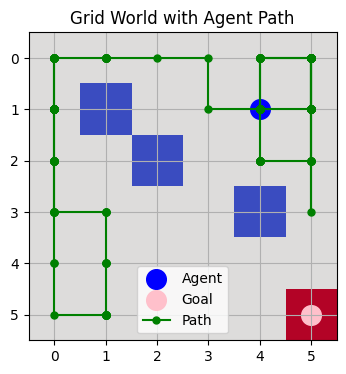

--- Episode 2 ---
Step 1: Moved from (0, 0) to (0, 0) with reward -10
Step 2: Moved from (0, 0) to (0, 0) with reward -10
Step 3: Moved from (0, 0) to (0, 0) with reward -10
Step 4: Moved from (0, 0) to (0, 0) with reward -10
Step 5: Moved from (0, 0) to (0, 0) with reward -10
Step 6: Moved from (0, 0) to (0, 0) with reward -10
Step 7: Moved from (0, 0) to (0, 0) with reward -10
Step 8: Moved from (0, 0) to (0, 0) with reward -10
Step 9: Moved from (0, 0) to (0, 0) with reward -10
Step 10: Moved from (0, 0) to (0, 0) with reward -10
Step 11: Moved from (0, 0) to (0, 0) with reward -10
Step 12: Moved from (0, 0) to (0, 0) with reward -10
Step 13: Moved from (0, 0) to (0, 0) with reward -10
Step 14: Moved from (0, 0) to (0, 0) with reward -10
Step 15: Moved from (0, 0) to (0, 0) with reward -10
Step 16: Moved from (0, 0) to (0, 0) with reward -10
Step 17: Moved from (0, 0) to (0, 0) with reward -10
Step 18: Moved from (0, 0) to (0, 0) with reward -10
Step 19: Moved from (0, 0) to (0, 0) 

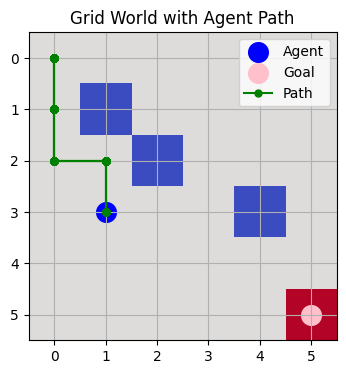

--- Episode 3 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (2, 1) with reward -1
Step 4: Moved from (2, 1) to (3, 1) with reward -1
Step 5: Moved from (3, 1) to (2, 1) with reward -1
Step 6: Moved from (2, 1) to (2, 1) with reward -10
Step 7: Moved from (2, 1) to (2, 1) with reward -10
Step 8: Moved from (2, 1) to (2, 1) with reward -10
Step 9: Moved from (2, 1) to (2, 1) with reward -10
Step 10: Moved from (2, 1) to (2, 1) with reward -10
Step 11: Moved from (2, 1) to (3, 1) with reward -1
Step 12: Moved from (3, 1) to (2, 1) with reward -1
Step 13: Moved from (2, 1) to (3, 1) with reward -1
Step 14: Moved from (3, 1) to (2, 1) with reward -1
Step 15: Moved from (2, 1) to (3, 1) with reward -1
Step 16: Moved from (3, 1) to (2, 1) with reward -1
Step 17: Moved from (2, 1) to (2, 1) with reward -10
Step 18: Moved from (2, 1) to (2, 1) with reward -10
Step 19: Moved from (2, 1) to (2, 1) with reward

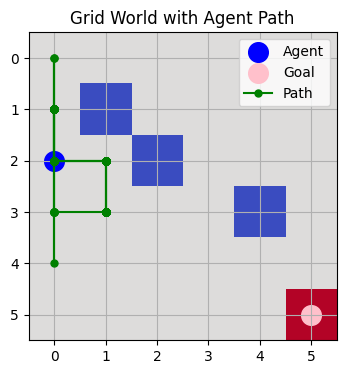

--- Episode 4 ---
Step 1: Moved from (0, 0) to (0, 0) with reward -10
Step 2: Moved from (0, 0) to (0, 0) with reward -10
Step 3: Moved from (0, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (0, 0) with reward -1
Step 7: Moved from (0, 0) to (0, 0) with reward -10
Step 8: Moved from (0, 0) to (0, 0) with reward -10
Step 9: Moved from (0, 0) to (0, 0) with reward -10
Step 10: Moved from (0, 0) to (1, 0) with reward -1
Step 11: Moved from (1, 0) to (2, 0) with reward -1
Step 12: Moved from (2, 0) to (3, 0) with reward -1
Step 13: Moved from (3, 0) to (2, 0) with reward -1
Step 14: Moved from (2, 0) to (3, 0) with reward -1
Step 15: Moved from (3, 0) to (2, 0) with reward -1
Step 16: Moved from (2, 0) to (3, 0) with reward -1
Step 17: Moved from (3, 0) to (2, 0) with reward -1
Step 18: Moved from (2, 0) to (3, 0) with reward -1
Step 19: Moved from (3, 0) to (2, 0) with reward -

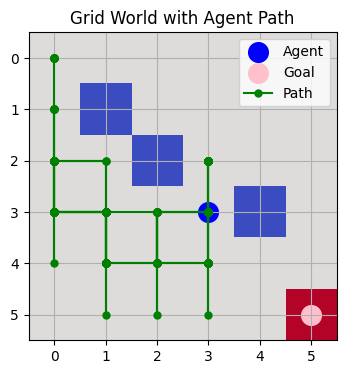

--- Episode 5 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (3, 0) with reward -1
Step 8: Moved from (3, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (3, 0) with reward -1
Step 10: Moved from (3, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (3, 0) with reward -1
Step 14: Moved from (3, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (3, 0) with reward -1
Step 16: Moved from (3, 0) to (3, 1) with reward -1
Step 17: Moved from (3, 1) to (4, 1) with reward -1
Step 18: Moved from (4, 1) to (3, 1) with reward -1
Step 19: Moved from (3, 1) to (4, 1) with reward -1
Ste

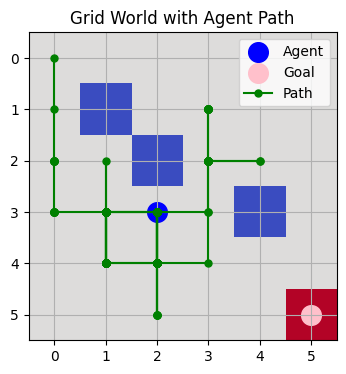

--- Episode 6 ---
Step 1: Moved from (0, 0) to (0, 0) with reward -10
Step 2: Moved from (0, 0) to (1, 0) with reward -1
Step 3: Moved from (1, 0) to (2, 0) with reward -1
Step 4: Moved from (2, 0) to (3, 0) with reward -1
Step 5: Moved from (3, 0) to (2, 0) with reward -1
Step 6: Moved from (2, 0) to (3, 0) with reward -1
Step 7: Moved from (3, 0) to (2, 0) with reward -1
Step 8: Moved from (2, 0) to (3, 0) with reward -1
Step 9: Moved from (3, 0) to (2, 0) with reward -1
Step 10: Moved from (2, 0) to (3, 0) with reward -1
Step 11: Moved from (3, 0) to (2, 0) with reward -1
Step 12: Moved from (2, 0) to (3, 0) with reward -1
Step 13: Moved from (3, 0) to (2, 0) with reward -1
Step 14: Moved from (2, 0) to (3, 0) with reward -1
Step 15: Moved from (3, 0) to (2, 0) with reward -1
Step 16: Moved from (2, 0) to (3, 0) with reward -1
Step 17: Moved from (3, 0) to (2, 0) with reward -1
Step 18: Moved from (2, 0) to (3, 0) with reward -1
Step 19: Moved from (3, 0) to (2, 0) with reward -1
St

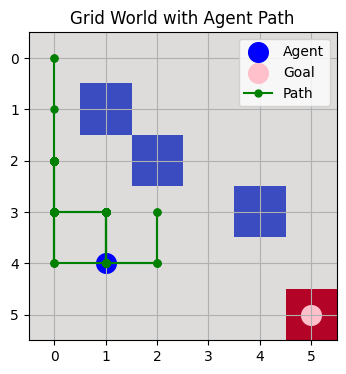

--- Episode 7 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (2, 1) with reward -1
Step 4: Moved from (2, 1) to (3, 1) with reward -1
Step 5: Moved from (3, 1) to (4, 1) with reward -1
Step 6: Moved from (4, 1) to (3, 1) with reward -1
Step 7: Moved from (3, 1) to (4, 1) with reward -1
Step 8: Moved from (4, 1) to (3, 1) with reward -1
Step 9: Moved from (3, 1) to (4, 1) with reward -1
Step 10: Moved from (4, 1) to (3, 1) with reward -1
Step 11: Moved from (3, 1) to (4, 1) with reward -1
Step 12: Moved from (4, 1) to (3, 1) with reward -1
Step 13: Moved from (3, 1) to (4, 1) with reward -1
Step 14: Moved from (4, 1) to (3, 1) with reward -1
Step 15: Moved from (3, 1) to (4, 1) with reward -1
Step 16: Moved from (4, 1) to (3, 1) with reward -1
Step 17: Moved from (3, 1) to (4, 1) with reward -1
Step 18: Moved from (4, 1) to (3, 1) with reward -1
Step 19: Moved from (3, 1) to (4, 1) with reward -1
Ste

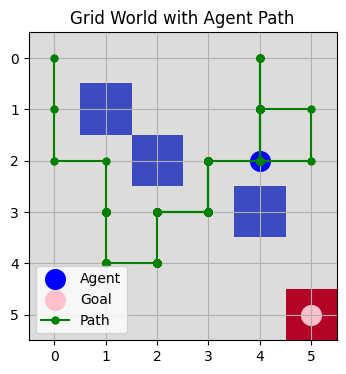

--- Episode 8 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (4, 0) with reward -1
Step 5: Moved from (4, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (3, 0) with reward -1
Step 8: Moved from (3, 0) to (4, 0) with reward -1
Step 9: Moved from (4, 0) to (3, 0) with reward -1
Step 10: Moved from (3, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (3, 0) with reward -1
Step 14: Moved from (3, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (3, 0) with reward -1
Step 16: Moved from (3, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (1, 0) with reward -1
Step 18: Moved from (1, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (3, 0) with reward -1
Ste

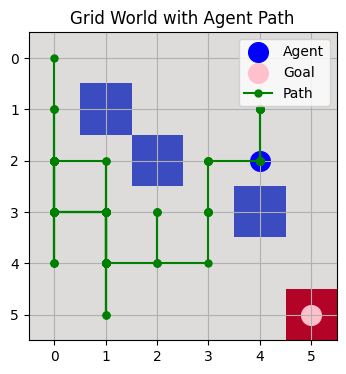

--- Episode 9 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (1, 0) with reward -10
Step 3: Moved from (1, 0) to (2, 0) with reward -1
Step 4: Moved from (2, 0) to (3, 0) with reward -1
Step 5: Moved from (3, 0) to (2, 0) with reward -1
Step 6: Moved from (2, 0) to (3, 0) with reward -1
Step 7: Moved from (3, 0) to (2, 0) with reward -1
Step 8: Moved from (2, 0) to (3, 0) with reward -1
Step 9: Moved from (3, 0) to (2, 0) with reward -1
Step 10: Moved from (2, 0) to (1, 0) with reward -1
Step 11: Moved from (1, 0) to (2, 0) with reward -1
Step 12: Moved from (2, 0) to (3, 0) with reward -1
Step 13: Moved from (3, 0) to (2, 0) with reward -1
Step 14: Moved from (2, 0) to (3, 0) with reward -1
Step 15: Moved from (3, 0) to (2, 0) with reward -1
Step 16: Moved from (2, 0) to (3, 0) with reward -1
Step 17: Moved from (3, 0) to (4, 0) with reward -1
Step 18: Moved from (4, 0) to (3, 0) with reward -1
Step 19: Moved from (3, 0) to (2, 0) with reward -1
St

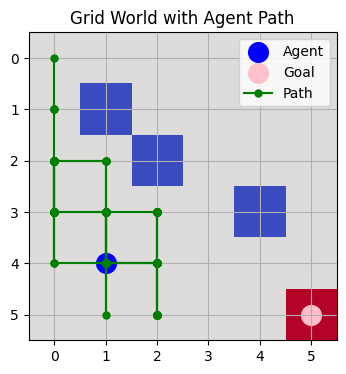

--- Episode 10 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (2, 0) with reward -10
Step 8: Moved from (2, 0) to (3, 0) with reward -1
Step 9: Moved from (3, 0) to (2, 0) with reward -1
Step 10: Moved from (2, 0) to (3, 0) with reward -1
Step 11: Moved from (3, 0) to (4, 0) with reward -1
Step 12: Moved from (4, 0) to (3, 0) with reward -1
Step 13: Moved from (3, 0) to (2, 0) with reward -1
Step 14: Moved from (2, 0) to (3, 0) with reward -1
Step 15: Moved from (3, 0) to (2, 0) with reward -1
Step 16: Moved from (2, 0) to (1, 0) with reward -1
Step 17: Moved from (1, 0) to (2, 0) with reward -1
Step 18: Moved from (2, 0) to (3, 0) with reward -1
Step 19: Moved from (3, 0) to (2, 0) with reward -1
S

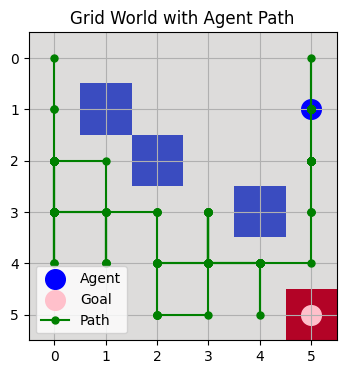

--- Episode 11 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (3, 0) with reward -1
Step 8: Moved from (3, 0) to (4, 0) with reward -1
Step 9: Moved from (4, 0) to (3, 0) with reward -1
Step 10: Moved from (3, 0) to (4, 0) with reward -1
Step 11: Moved from (4, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (4, 0) with reward -1
Step 13: Moved from (4, 0) to (3, 0) with reward -1
Step 14: Moved from (3, 0) to (4, 0) with reward -1
Step 15: Moved from (4, 0) to (3, 0) with reward -1
Step 16: Moved from (3, 0) to (4, 0) with reward -1
Step 17: Moved from (4, 0) to (3, 0) with reward -1
Step 18: Moved from (3, 0) to (4, 0) with reward -1
Step 19: Moved from (4, 0) to (3, 0) with reward -1
St

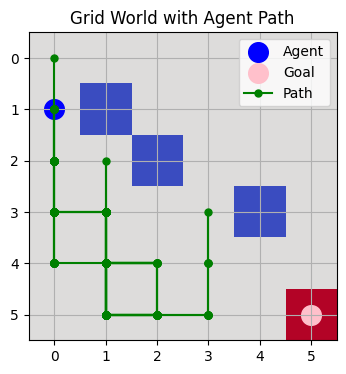

--- Episode 12 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (2, 1) with reward -1
Step 4: Moved from (2, 1) to (3, 1) with reward -1
Step 5: Moved from (3, 1) to (4, 1) with reward -1
Step 6: Moved from (4, 1) to (3, 1) with reward -1
Step 7: Moved from (3, 1) to (4, 1) with reward -1
Step 8: Moved from (4, 1) to (4, 2) with reward -1
Step 9: Moved from (4, 2) to (4, 1) with reward -1
Step 10: Moved from (4, 1) to (3, 1) with reward -1
Step 11: Moved from (3, 1) to (3, 2) with reward -1
Step 12: Moved from (3, 2) to (4, 2) with reward -1
Step 13: Moved from (4, 2) to (4, 1) with reward -1
Step 14: Moved from (4, 1) to (3, 1) with reward -1
Step 15: Moved from (3, 1) to (4, 1) with reward -1
Step 16: Moved from (4, 1) to (4, 2) with reward -1
Step 17: Moved from (4, 2) to (4, 1) with reward -1
Step 18: Moved from (4, 1) to (4, 2) with reward -1
Step 19: Moved from (4, 2) to (4, 1) with reward -1
St

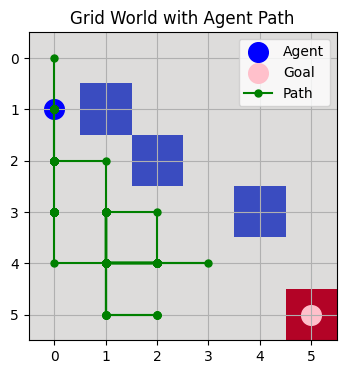

--- Episode 13 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (3, 0) with reward -1
Step 8: Moved from (3, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (3, 0) with reward -1
Step 10: Moved from (3, 0) to (4, 0) with reward -1
Step 11: Moved from (4, 0) to (4, 1) with reward -1
Step 12: Moved from (4, 1) to (4, 2) with reward -1
Step 13: Moved from (4, 2) to (4, 1) with reward -1
Step 14: Moved from (4, 1) to (4, 2) with reward -1
Step 15: Moved from (4, 2) to (4, 1) with reward -1
Step 16: Moved from (4, 1) to (4, 2) with reward -1
Step 17: Moved from (4, 2) to (4, 1) with reward -1
Step 18: Moved from (4, 1) to (4, 2) with reward -1
Step 19: Moved from (4, 2) to (4, 1) with reward -1
St

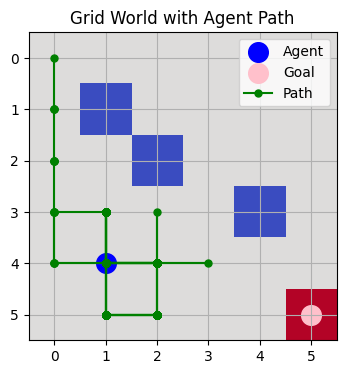

--- Episode 14 ---
Step 1: Moved from (0, 0) to (0, 0) with reward -10
Step 2: Moved from (0, 0) to (1, 0) with reward -1
Step 3: Moved from (1, 0) to (2, 0) with reward -1
Step 4: Moved from (2, 0) to (3, 0) with reward -1
Step 5: Moved from (3, 0) to (2, 0) with reward -1
Step 6: Moved from (2, 0) to (1, 0) with reward -1
Step 7: Moved from (1, 0) to (2, 0) with reward -1
Step 8: Moved from (2, 0) to (1, 0) with reward -1
Step 9: Moved from (1, 0) to (2, 0) with reward -1
Step 10: Moved from (2, 0) to (1, 0) with reward -1
Step 11: Moved from (1, 0) to (2, 0) with reward -1
Step 12: Moved from (2, 0) to (1, 0) with reward -1
Step 13: Moved from (1, 0) to (2, 0) with reward -1
Step 14: Moved from (2, 0) to (1, 0) with reward -1
Step 15: Moved from (1, 0) to (2, 0) with reward -1
Step 16: Moved from (2, 0) to (1, 0) with reward -1
Step 17: Moved from (1, 0) to (2, 0) with reward -1
Step 18: Moved from (2, 0) to (1, 0) with reward -1
Step 19: Moved from (1, 0) to (2, 0) with reward -1
S

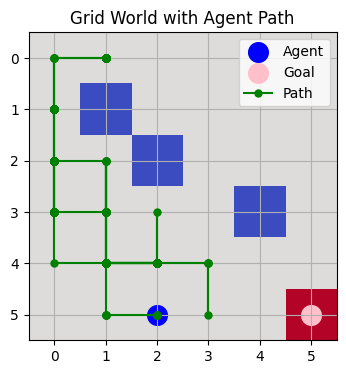

--- Episode 15 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (1, 0) with reward -10
Step 3: Moved from (1, 0) to (2, 0) with reward -1
Step 4: Moved from (2, 0) to (3, 0) with reward -1
Step 5: Moved from (3, 0) to (4, 0) with reward -1
Step 6: Moved from (4, 0) to (5, 0) with reward -1
Step 7: Moved from (5, 0) to (4, 0) with reward -1
Step 8: Moved from (4, 0) to (5, 0) with reward -1
Step 9: Moved from (5, 0) to (4, 0) with reward -1
Step 10: Moved from (4, 0) to (5, 0) with reward -1
Step 11: Moved from (5, 0) to (5, 1) with reward -1
Step 12: Moved from (5, 1) to (4, 1) with reward -1
Step 13: Moved from (4, 1) to (5, 1) with reward -1
Step 14: Moved from (5, 1) to (4, 1) with reward -1
Step 15: Moved from (4, 1) to (5, 1) with reward -1
Step 16: Moved from (5, 1) to (4, 1) with reward -1
Step 17: Moved from (4, 1) to (5, 1) with reward -1
Step 18: Moved from (5, 1) to (4, 1) with reward -1
Step 19: Moved from (4, 1) to (5, 1) with reward -1
S

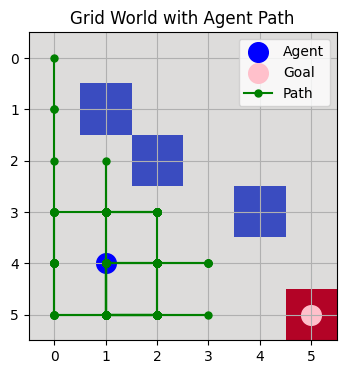

--- Episode 16 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (4, 0) with reward -1
Step 5: Moved from (4, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (4, 0) with reward -1
Step 7: Moved from (4, 0) to (3, 0) with reward -1
Step 8: Moved from (3, 0) to (4, 0) with reward -1
Step 9: Moved from (4, 0) to (3, 0) with reward -1
Step 10: Moved from (3, 0) to (4, 0) with reward -1
Step 11: Moved from (4, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (4, 0) with reward -1
Step 13: Moved from (4, 0) to (3, 0) with reward -1
Step 14: Moved from (3, 0) to (4, 0) with reward -1
Step 15: Moved from (4, 0) to (3, 0) with reward -1
Step 16: Moved from (3, 0) to (4, 0) with reward -1
Step 17: Moved from (4, 0) to (3, 0) with reward -1
Step 18: Moved from (3, 0) to (4, 0) with reward -1
Step 19: Moved from (4, 0) to (3, 0) with reward -1
St

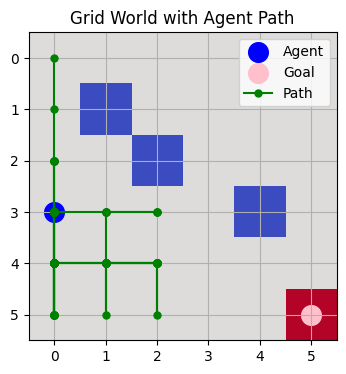

--- Episode 17 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (4, 0) with reward -1
Step 5: Moved from (4, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (4, 0) with reward -1
Step 7: Moved from (4, 0) to (3, 0) with reward -1
Step 8: Moved from (3, 0) to (4, 0) with reward -1
Step 9: Moved from (4, 0) to (3, 0) with reward -1
Step 10: Moved from (3, 0) to (4, 0) with reward -1
Step 11: Moved from (4, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (4, 0) with reward -1
Step 13: Moved from (4, 0) to (3, 0) with reward -1
Step 14: Moved from (3, 0) to (4, 0) with reward -1
Step 15: Moved from (4, 0) to (3, 0) with reward -1
Step 16: Moved from (3, 0) to (4, 0) with reward -1
Step 17: Moved from (4, 0) to (3, 0) with reward -1
Step 18: Moved from (3, 0) to (4, 0) with reward -1
Step 19: Moved from (4, 0) to (3, 0) with reward -1
St

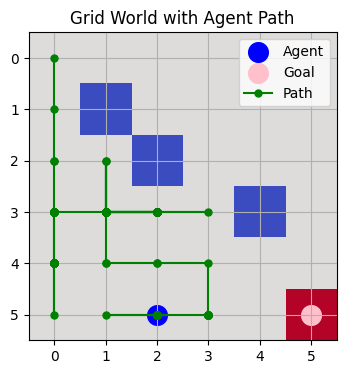

--- Episode 18 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (3, 0) with reward -1
Step 8: Moved from (3, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (3, 0) with reward -1
Step 10: Moved from (3, 0) to (4, 0) with reward -1
Step 11: Moved from (4, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (3, 0) with reward -1
Step 14: Moved from (3, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (3, 0) with reward -1
Step 16: Moved from (3, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (3, 0) with reward -1
Step 18: Moved from (3, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (3, 0) with reward -1
St

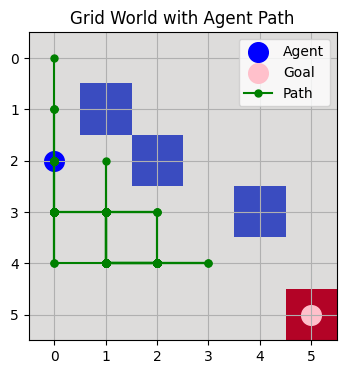

--- Episode 19 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (3, 0) with reward -10
Step 7: Moved from (3, 0) to (2, 0) with reward -1
Step 8: Moved from (2, 0) to (3, 0) with reward -1
Step 9: Moved from (3, 0) to (2, 0) with reward -1
Step 10: Moved from (2, 0) to (3, 0) with reward -1
Step 11: Moved from (3, 0) to (2, 0) with reward -1
Step 12: Moved from (2, 0) to (3, 0) with reward -1
Step 13: Moved from (3, 0) to (2, 0) with reward -1
Step 14: Moved from (2, 0) to (3, 0) with reward -1
Step 15: Moved from (3, 0) to (2, 0) with reward -1
Step 16: Moved from (2, 0) to (3, 0) with reward -1
Step 17: Moved from (3, 0) to (2, 0) with reward -1
Step 18: Moved from (2, 0) to (3, 0) with reward -1
Step 19: Moved from (3, 0) to (2, 0) with reward -1
S

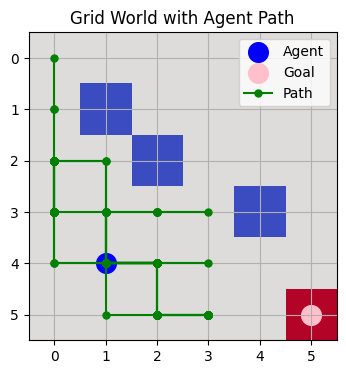

--- Episode 20 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (4, 0) with reward -1
Step 5: Moved from (4, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (3, 0) with reward -1
Step 8: Moved from (3, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (3, 0) with reward -1
Step 10: Moved from (3, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (3, 0) with reward -1
Step 14: Moved from (3, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (3, 0) with reward -1
Step 16: Moved from (3, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (3, 0) with reward -1
Step 18: Moved from (3, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (2, 1) with reward -1
St

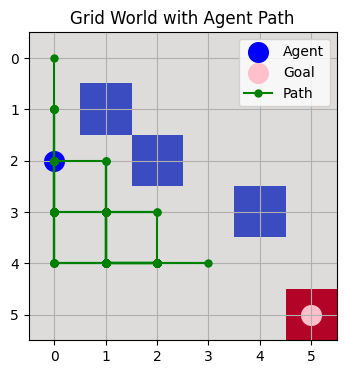

--- Episode 21 ---
Step 1: Moved from (0, 0) to (0, 0) with reward -10
Step 2: Moved from (0, 0) to (1, 0) with reward -1
Step 3: Moved from (1, 0) to (2, 0) with reward -1
Step 4: Moved from (2, 0) to (2, 1) with reward -1
Step 5: Moved from (2, 1) to (3, 1) with reward -1
Step 6: Moved from (3, 1) to (4, 1) with reward -1
Step 7: Moved from (4, 1) to (4, 2) with reward -1
Step 8: Moved from (4, 2) to (4, 1) with reward -1
Step 9: Moved from (4, 1) to (4, 2) with reward -1
Step 10: Moved from (4, 2) to (4, 1) with reward -1
Step 11: Moved from (4, 1) to (4, 0) with reward -1
Step 12: Moved from (4, 0) to (3, 0) with reward -1
Step 13: Moved from (3, 0) to (2, 0) with reward -1
Step 14: Moved from (2, 0) to (3, 0) with reward -1
Step 15: Moved from (3, 0) to (2, 0) with reward -1
Step 16: Moved from (2, 0) to (3, 0) with reward -1
Step 17: Moved from (3, 0) to (2, 0) with reward -1
Step 18: Moved from (2, 0) to (3, 0) with reward -1
Step 19: Moved from (3, 0) to (2, 0) with reward -1
S

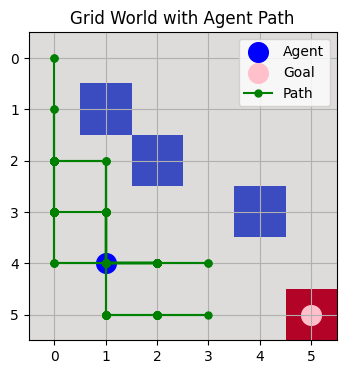

--- Episode 22 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (1, 0) with reward -1
Step 8: Moved from (1, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (1, 0) with reward -1
Step 10: Moved from (1, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (1, 0) with reward -1
Step 12: Moved from (1, 0) to (1, 0) with reward -10
Step 13: Moved from (1, 0) to (2, 0) with reward -1
Step 14: Moved from (2, 0) to (1, 0) with reward -1
Step 15: Moved from (1, 0) to (2, 0) with reward -1
Step 16: Moved from (2, 0) to (1, 0) with reward -1
Step 17: Moved from (1, 0) to (1, 0) with reward -10
Step 18: Moved from (1, 0) to (1, 0) with reward -10
Step 19: Moved from (1, 0) to (2, 0) with reward -1

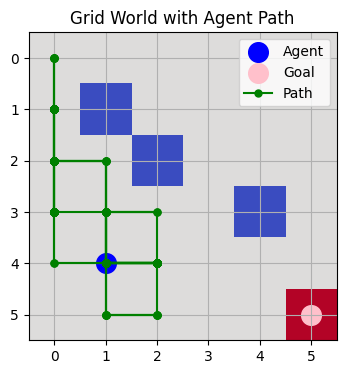

--- Episode 23 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (1, 0) with reward -1
Step 8: Moved from (1, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (1, 0) with reward -1
Step 10: Moved from (1, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (1, 0) with reward -1
Step 12: Moved from (1, 0) to (0, 0) with reward -1
Step 13: Moved from (0, 0) to (1, 0) with reward -1
Step 14: Moved from (1, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (1, 0) with reward -1
Step 16: Moved from (1, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (1, 0) with reward -1
Step 18: Moved from (1, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (1, 0) with reward -1
St

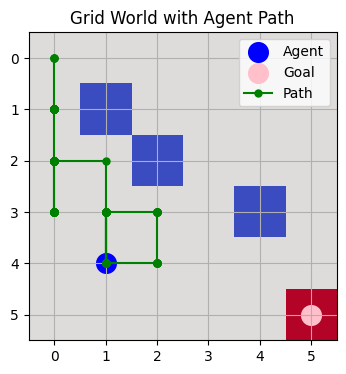

--- Episode 24 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (1, 0) with reward -10
Step 7: Moved from (1, 0) to (2, 0) with reward -1
Step 8: Moved from (2, 0) to (1, 0) with reward -1
Step 9: Moved from (1, 0) to (2, 0) with reward -1
Step 10: Moved from (2, 0) to (1, 0) with reward -1
Step 11: Moved from (1, 0) to (0, 0) with reward -1
Step 12: Moved from (0, 0) to (1, 0) with reward -1
Step 13: Moved from (1, 0) to (2, 0) with reward -1
Step 14: Moved from (2, 0) to (1, 0) with reward -1
Step 15: Moved from (1, 0) to (2, 0) with reward -1
Step 16: Moved from (2, 0) to (1, 0) with reward -1
Step 17: Moved from (1, 0) to (2, 0) with reward -1
Step 18: Moved from (2, 0) to (3, 0) with reward -1
Step 19: Moved from (3, 0) to (4, 0) with reward -1
S

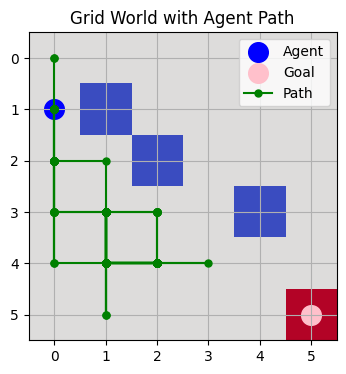

--- Episode 25 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (0, 0) with reward -1
Step 3: Moved from (0, 0) to (0, 1) with reward -1
Step 4: Moved from (0, 1) to (0, 0) with reward -1
Step 5: Moved from (0, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (1, 0) with reward -1
Step 8: Moved from (1, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (1, 0) with reward -1
Step 10: Moved from (1, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (1, 0) with reward -1
Step 12: Moved from (1, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (1, 0) with reward -1
Step 14: Moved from (1, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (1, 0) with reward -1
Step 16: Moved from (1, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (1, 0) with reward -1
Step 18: Moved from (1, 0) to (1, 0) with reward -10
Step 19: Moved from (1, 0) to (2, 0) with reward -1
S

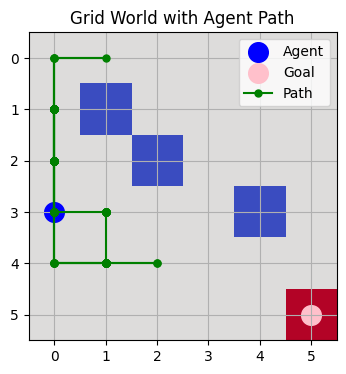

--- Episode 26 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (3, 0) with reward -1
Step 8: Moved from (3, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (3, 0) with reward -1
Step 10: Moved from (3, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (3, 0) with reward -1
Step 14: Moved from (3, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (3, 0) with reward -1
Step 16: Moved from (3, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (2, 1) with reward -1
Step 18: Moved from (2, 1) to (3, 1) with reward -1
Step 19: Moved from (3, 1) to (4, 1) with reward -1
St

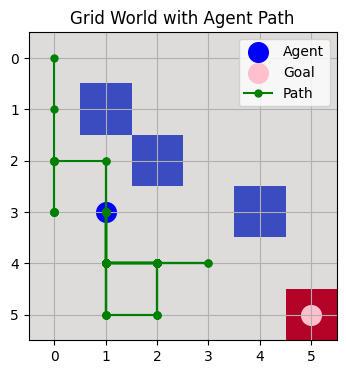

--- Episode 27 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (1, 0) with reward -1
Step 8: Moved from (1, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (1, 0) with reward -1
Step 10: Moved from (1, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (3, 0) with reward -1
Step 14: Moved from (3, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (3, 0) with reward -1
Step 16: Moved from (3, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (3, 0) with reward -1
Step 18: Moved from (3, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (3, 0) with reward -1
St

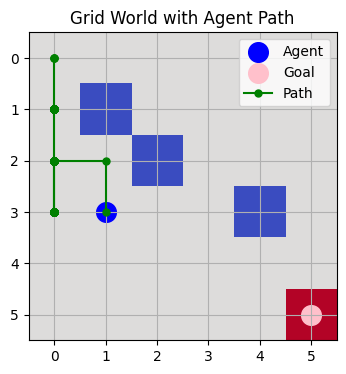

--- Episode 28 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (1, 0) with reward -1
Step 8: Moved from (1, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (1, 0) with reward -1
Step 10: Moved from (1, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (1, 0) with reward -1
Step 12: Moved from (1, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (1, 0) with reward -1
Step 14: Moved from (1, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (1, 0) with reward -1
Step 16: Moved from (1, 0) to (1, 0) with reward -10
Step 17: Moved from (1, 0) to (1, 0) with reward -10
Step 18: Moved from (1, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (1, 0) with reward -1


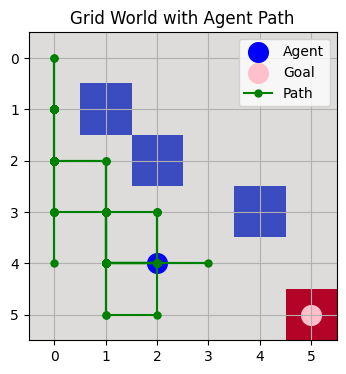

--- Episode 29 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (1, 0) with reward -10
Step 7: Moved from (1, 0) to (2, 0) with reward -1
Step 8: Moved from (2, 0) to (1, 0) with reward -1
Step 9: Moved from (1, 0) to (2, 0) with reward -1
Step 10: Moved from (2, 0) to (1, 0) with reward -1
Step 11: Moved from (1, 0) to (1, 0) with reward -10
Step 12: Moved from (1, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (1, 0) with reward -1
Step 14: Moved from (1, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (1, 0) with reward -1
Step 16: Moved from (1, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (1, 0) with reward -1
Step 18: Moved from (1, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (3, 0) with reward -1


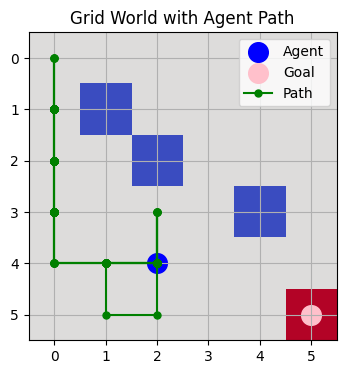

--- Episode 30 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (1, 0) with reward -1
Step 8: Moved from (1, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (1, 0) with reward -1
Step 10: Moved from (1, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (1, 0) with reward -1
Step 12: Moved from (1, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (3, 0) with reward -1
Step 14: Moved from (3, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (1, 0) with reward -1
Step 16: Moved from (1, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (2, 1) with reward -1
Step 18: Moved from (2, 1) to (3, 1) with reward -1
Step 19: Moved from (3, 1) to (4, 1) with reward -1
St

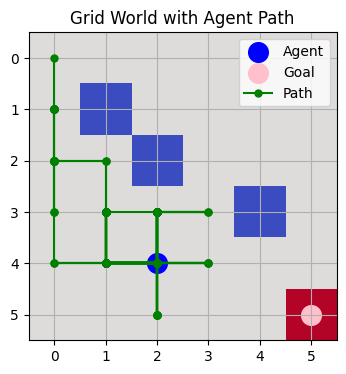

--- Episode 31 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (3, 0) with reward -1
Step 8: Moved from (3, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (3, 0) with reward -1
Step 10: Moved from (3, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (3, 0) with reward -1
Step 14: Moved from (3, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (3, 0) with reward -1
Step 16: Moved from (3, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (3, 0) with reward -1
Step 18: Moved from (3, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (3, 0) with reward -1
St

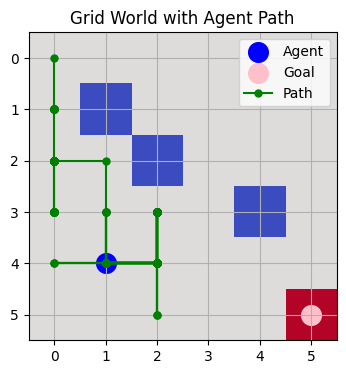

--- Episode 32 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (1, 0) with reward -1
Step 8: Moved from (1, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (3, 0) with reward -1
Step 10: Moved from (3, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (1, 0) with reward -1
Step 14: Moved from (1, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (1, 0) with reward -1
Step 16: Moved from (1, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (1, 0) with reward -1
Step 18: Moved from (1, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (1, 0) with reward -1
St

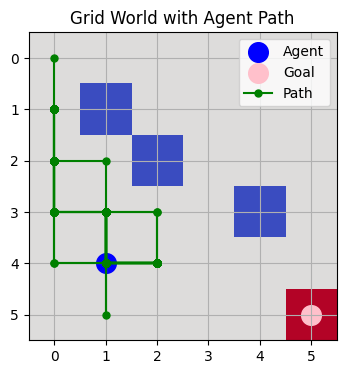

--- Episode 33 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (4, 0) with reward -1
Step 5: Moved from (4, 0) to (4, 1) with reward -1
Step 6: Moved from (4, 1) to (4, 2) with reward -1
Step 7: Moved from (4, 2) to (3, 2) with reward -1
Step 8: Moved from (3, 2) to (4, 2) with reward -1
Step 9: Moved from (4, 2) to (4, 1) with reward -1
Step 10: Moved from (4, 1) to (3, 1) with reward -1
Step 11: Moved from (3, 1) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (1, 0) with reward -1
Step 14: Moved from (1, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (3, 0) with reward -1
Step 16: Moved from (3, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (3, 0) with reward -1
Step 18: Moved from (3, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (3, 0) with reward -1
St

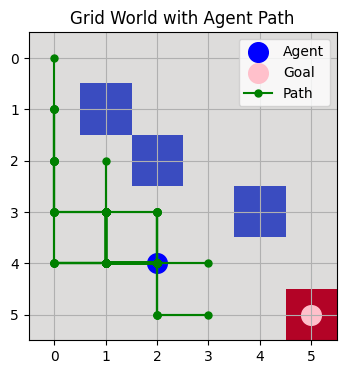

--- Episode 34 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (1, 0) with reward -1
Step 8: Moved from (1, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (1, 0) with reward -1
Step 10: Moved from (1, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (4, 0) with reward -1
Step 13: Moved from (4, 0) to (4, 1) with reward -1
Step 14: Moved from (4, 1) to (4, 2) with reward -1
Step 15: Moved from (4, 2) to (4, 1) with reward -1
Step 16: Moved from (4, 1) to (4, 2) with reward -1
Step 17: Moved from (4, 2) to (4, 1) with reward -1
Step 18: Moved from (4, 1) to (4, 2) with reward -1
Step 19: Moved from (4, 2) to (4, 1) with reward -1
St

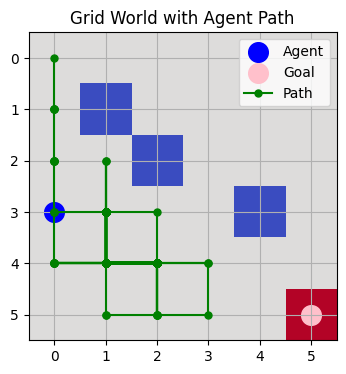

--- Episode 35 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (4, 0) with reward -1
Step 5: Moved from (4, 0) to (4, 1) with reward -1
Step 6: Moved from (4, 1) to (4, 2) with reward -1
Step 7: Moved from (4, 2) to (4, 1) with reward -1
Step 8: Moved from (4, 1) to (3, 1) with reward -1
Step 9: Moved from (3, 1) to (4, 1) with reward -1
Step 10: Moved from (4, 1) to (4, 2) with reward -1
Step 11: Moved from (4, 2) to (4, 1) with reward -1
Step 12: Moved from (4, 1) to (3, 1) with reward -1
Step 13: Moved from (3, 1) to (4, 1) with reward -1
Step 14: Moved from (4, 1) to (3, 1) with reward -1
Step 15: Moved from (3, 1) to (4, 1) with reward -1
Step 16: Moved from (4, 1) to (3, 1) with reward -1
Step 17: Moved from (3, 1) to (4, 1) with reward -1
Step 18: Moved from (4, 1) to (4, 2) with reward -1
Step 19: Moved from (4, 2) to (4, 1) with reward -1
St

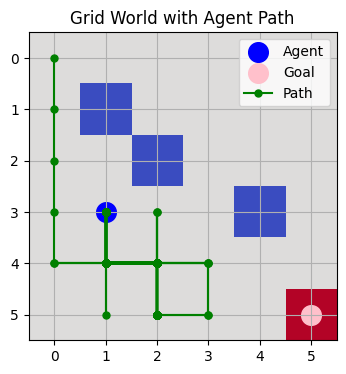

--- Episode 36 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (3, 1) with reward -1
Step 7: Moved from (3, 1) to (4, 1) with reward -1
Step 8: Moved from (4, 1) to (4, 2) with reward -1
Step 9: Moved from (4, 2) to (4, 1) with reward -1
Step 10: Moved from (4, 1) to (4, 2) with reward -1
Step 11: Moved from (4, 2) to (4, 1) with reward -1
Step 12: Moved from (4, 1) to (3, 1) with reward -1
Step 13: Moved from (3, 1) to (3, 2) with reward -1
Step 14: Moved from (3, 2) to (4, 2) with reward -1
Step 15: Moved from (4, 2) to (3, 2) with reward -1
Step 16: Moved from (3, 2) to (4, 2) with reward -1
Step 17: Moved from (4, 2) to (4, 1) with reward -1
Step 18: Moved from (4, 1) to (3, 1) with reward -1
Step 19: Moved from (3, 1) to (4, 1) with reward -1
St

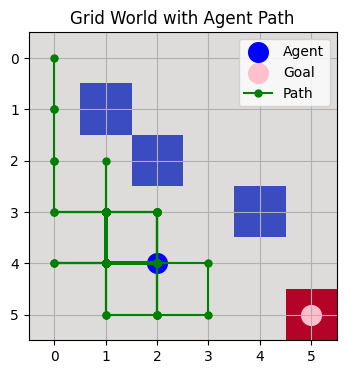

--- Episode 37 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (1, 0) with reward -10
Step 5: Moved from (1, 0) to (2, 0) with reward -1
Step 6: Moved from (2, 0) to (1, 0) with reward -1
Step 7: Moved from (1, 0) to (2, 0) with reward -1
Step 8: Moved from (2, 0) to (1, 0) with reward -1
Step 9: Moved from (1, 0) to (2, 0) with reward -1
Step 10: Moved from (2, 0) to (1, 0) with reward -1
Step 11: Moved from (1, 0) to (2, 0) with reward -1
Step 12: Moved from (2, 0) to (1, 0) with reward -1
Step 13: Moved from (1, 0) to (2, 0) with reward -1
Step 14: Moved from (2, 0) to (1, 0) with reward -1
Step 15: Moved from (1, 0) to (2, 0) with reward -1
Step 16: Moved from (2, 0) to (1, 0) with reward -1
Step 17: Moved from (1, 0) to (2, 0) with reward -1
Step 18: Moved from (2, 0) to (1, 0) with reward -1
Step 19: Moved from (1, 0) to (2, 0) with reward -1
S

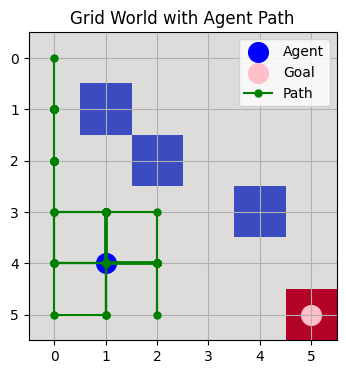

--- Episode 38 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (1, 0) with reward -1
Step 8: Moved from (1, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (1, 0) with reward -1
Step 10: Moved from (1, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (1, 0) with reward -1
Step 12: Moved from (1, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (1, 0) with reward -1
Step 14: Moved from (1, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (1, 0) with reward -1
Step 16: Moved from (1, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (1, 0) with reward -1
Step 18: Moved from (1, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (1, 0) with reward -1
St

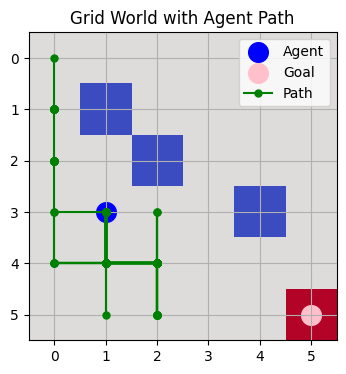

--- Episode 39 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (1, 0) with reward -1
Step 8: Moved from (1, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (1, 0) with reward -1
Step 10: Moved from (1, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (1, 0) with reward -1
Step 12: Moved from (1, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (1, 0) with reward -1
Step 14: Moved from (1, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (1, 0) with reward -1
Step 16: Moved from (1, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (3, 0) with reward -1
Step 18: Moved from (3, 0) to (4, 0) with reward -1
Step 19: Moved from (4, 0) to (4, 0) with reward -10
S

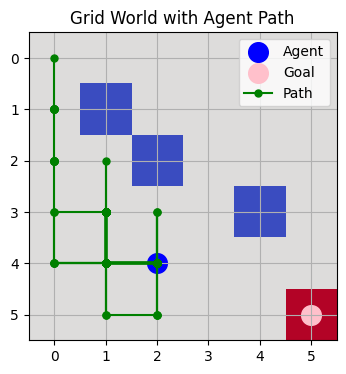

--- Episode 40 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (1, 0) with reward -1
Step 8: Moved from (1, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (1, 0) with reward -1
Step 10: Moved from (1, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (1, 0) with reward -1
Step 12: Moved from (1, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (1, 0) with reward -1
Step 14: Moved from (1, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (1, 0) with reward -1
Step 16: Moved from (1, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (1, 0) with reward -1
Step 18: Moved from (1, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (1, 0) with reward -1
St

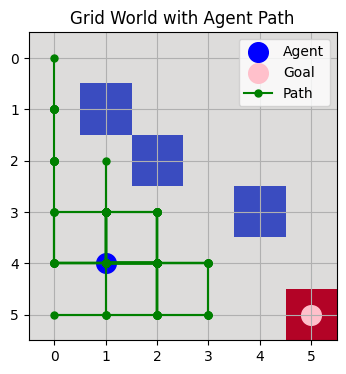

--- Episode 41 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (1, 0) with reward -10
Step 3: Moved from (1, 0) to (2, 0) with reward -1
Step 4: Moved from (2, 0) to (3, 0) with reward -1
Step 5: Moved from (3, 0) to (4, 0) with reward -1
Step 6: Moved from (4, 0) to (4, 1) with reward -1
Step 7: Moved from (4, 1) to (4, 2) with reward -1
Step 8: Moved from (4, 2) to (4, 1) with reward -1
Step 9: Moved from (4, 1) to (3, 1) with reward -1
Step 10: Moved from (3, 1) to (4, 1) with reward -1
Step 11: Moved from (4, 1) to (4, 0) with reward -1
Step 12: Moved from (4, 0) to (5, 0) with reward -1
Step 13: Moved from (5, 0) to (5, 1) with reward -1
Step 14: Moved from (5, 1) to (4, 1) with reward -1
Step 15: Moved from (4, 1) to (3, 1) with reward -1
Step 16: Moved from (3, 1) to (4, 1) with reward -1
Step 17: Moved from (4, 1) to (4, 2) with reward -1
Step 18: Moved from (4, 2) to (4, 1) with reward -1
Step 19: Moved from (4, 1) to (4, 2) with reward -1
S

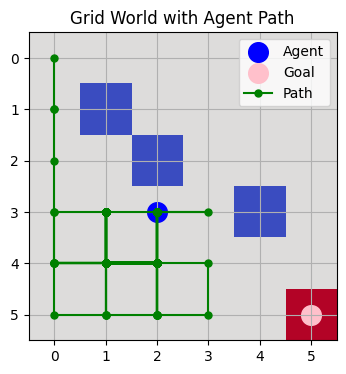

--- Episode 42 ---
Step 1: Moved from (0, 0) to (0, 0) with reward -10
Step 2: Moved from (0, 0) to (1, 0) with reward -1
Step 3: Moved from (1, 0) to (2, 0) with reward -1
Step 4: Moved from (2, 0) to (1, 0) with reward -1
Step 5: Moved from (1, 0) to (2, 0) with reward -1
Step 6: Moved from (2, 0) to (1, 0) with reward -1
Step 7: Moved from (1, 0) to (2, 0) with reward -1
Step 8: Moved from (2, 0) to (1, 0) with reward -1
Step 9: Moved from (1, 0) to (2, 0) with reward -1
Step 10: Moved from (2, 0) to (1, 0) with reward -1
Step 11: Moved from (1, 0) to (2, 0) with reward -1
Step 12: Moved from (2, 0) to (3, 0) with reward -1
Step 13: Moved from (3, 0) to (4, 0) with reward -1
Step 14: Moved from (4, 0) to (4, 1) with reward -1
Step 15: Moved from (4, 1) to (4, 2) with reward -1
Step 16: Moved from (4, 2) to (3, 2) with reward -1
Step 17: Moved from (3, 2) to (4, 2) with reward -1
Step 18: Moved from (4, 2) to (3, 2) with reward -1
Step 19: Moved from (3, 2) to (4, 2) with reward -1
S

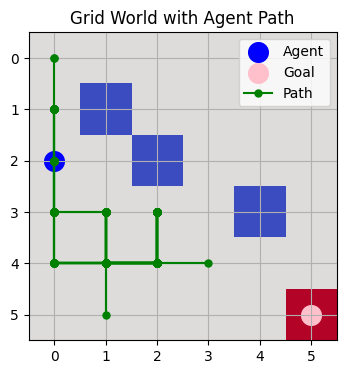

--- Episode 43 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (4, 0) with reward -1
Step 7: Moved from (4, 0) to (3, 0) with reward -1
Step 8: Moved from (3, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (3, 0) with reward -1
Step 10: Moved from (3, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (2, 0) with reward -1
Step 13: Moved from (2, 0) to (3, 0) with reward -1
Step 14: Moved from (3, 0) to (2, 0) with reward -1
Step 15: Moved from (2, 0) to (3, 0) with reward -1
Step 16: Moved from (3, 0) to (2, 0) with reward -1
Step 17: Moved from (2, 0) to (3, 0) with reward -1
Step 18: Moved from (3, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (3, 0) with reward -1
St

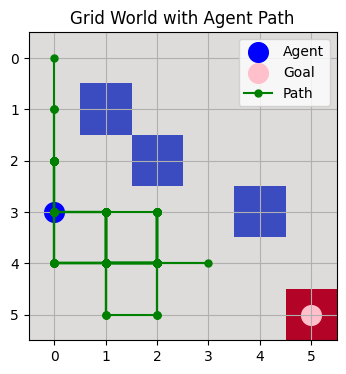

--- Episode 44 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (3, 0) with reward -1
Step 8: Moved from (3, 0) to (4, 0) with reward -1
Step 9: Moved from (4, 0) to (4, 1) with reward -1
Step 10: Moved from (4, 1) to (4, 2) with reward -1
Step 11: Moved from (4, 2) to (3, 2) with reward -1
Step 12: Moved from (3, 2) to (4, 2) with reward -1
Step 13: Moved from (4, 2) to (3, 2) with reward -1
Step 14: Moved from (3, 2) to (3, 2) with reward -10
Step 15: Moved from (3, 2) to (4, 2) with reward -1
Step 16: Moved from (4, 2) to (3, 2) with reward -1
Step 17: Moved from (3, 2) to (4, 2) with reward -1
Step 18: Moved from (4, 2) to (4, 1) with reward -1
Step 19: Moved from (4, 1) to (4, 2) with reward -1
S

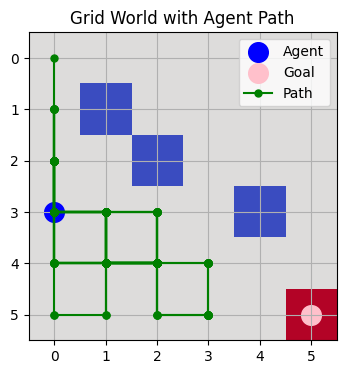

--- Episode 45 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (2, 1) with reward -1
Step 4: Moved from (2, 1) to (3, 1) with reward -1
Step 5: Moved from (3, 1) to (4, 1) with reward -1
Step 6: Moved from (4, 1) to (4, 2) with reward -1
Step 7: Moved from (4, 2) to (4, 3) with reward -1
Step 8: Moved from (4, 3) to (5, 3) with reward -1
Step 9: Moved from (5, 3) to (5, 2) with reward -1
Step 10: Moved from (5, 2) to (4, 2) with reward -1
Step 11: Moved from (4, 2) to (4, 1) with reward -1
Step 12: Moved from (4, 1) to (3, 1) with reward -1
Step 13: Moved from (3, 1) to (4, 1) with reward -1
Step 14: Moved from (4, 1) to (3, 1) with reward -1
Step 15: Moved from (3, 1) to (4, 1) with reward -1
Step 16: Moved from (4, 1) to (3, 1) with reward -1
Step 17: Moved from (3, 1) to (3, 0) with reward -1
Step 18: Moved from (3, 0) to (2, 0) with reward -1
Step 19: Moved from (2, 0) to (1, 0) with reward -1
St

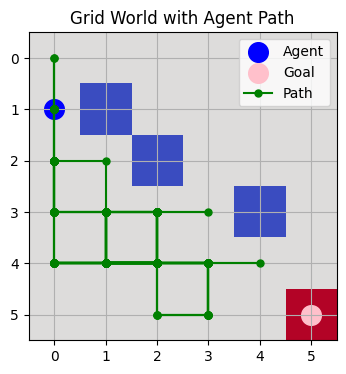

--- Episode 46 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (3, 1) with reward -1
Step 7: Moved from (3, 1) to (4, 1) with reward -1
Step 8: Moved from (4, 1) to (3, 1) with reward -1
Step 9: Moved from (3, 1) to (2, 1) with reward -1
Step 10: Moved from (2, 1) to (3, 1) with reward -1
Step 11: Moved from (3, 1) to (3, 2) with reward -1
Step 12: Moved from (3, 2) to (4, 2) with reward -1
Step 13: Moved from (4, 2) to (3, 2) with reward -1
Step 14: Moved from (3, 2) to (4, 2) with reward -1
Step 15: Moved from (4, 2) to (3, 2) with reward -1
Step 16: Moved from (3, 2) to (4, 2) with reward -1
Step 17: Moved from (4, 2) to (4, 1) with reward -1
Step 18: Moved from (4, 1) to (3, 1) with reward -1
Step 19: Moved from (3, 1) to (4, 1) with reward -1
St

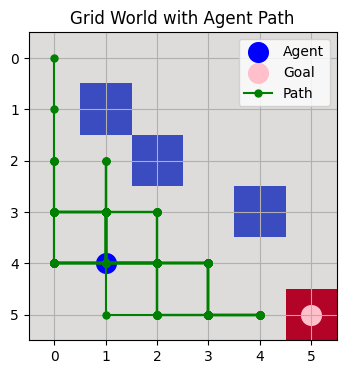

--- Episode 47 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (3, 1) with reward -1
Step 5: Moved from (3, 1) to (3, 0) with reward -1
Step 6: Moved from (3, 0) to (3, 1) with reward -1
Step 7: Moved from (3, 1) to (3, 0) with reward -1
Step 8: Moved from (3, 0) to (3, 1) with reward -1
Step 9: Moved from (3, 1) to (3, 0) with reward -1
Step 10: Moved from (3, 0) to (3, 1) with reward -1
Step 11: Moved from (3, 1) to (4, 1) with reward -1
Step 12: Moved from (4, 1) to (4, 2) with reward -1
Step 13: Moved from (4, 2) to (4, 3) with reward -1
Step 14: Moved from (4, 3) to (4, 2) with reward -1
Step 15: Moved from (4, 2) to (4, 3) with reward -1
Step 16: Moved from (4, 3) to (4, 2) with reward -1
Step 17: Moved from (4, 2) to (4, 3) with reward -1
Step 18: Moved from (4, 3) to (4, 2) with reward -1
Step 19: Moved from (4, 2) to (4, 1) with reward -1
St

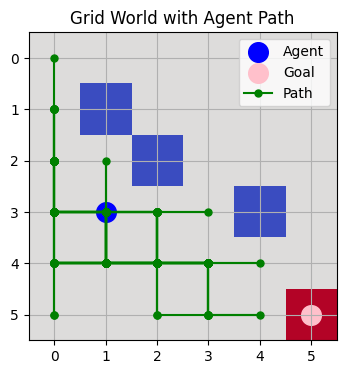

--- Episode 48 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (1, 0) with reward -1
Step 8: Moved from (1, 0) to (2, 0) with reward -1
Step 9: Moved from (2, 0) to (1, 0) with reward -1
Step 10: Moved from (1, 0) to (2, 0) with reward -1
Step 11: Moved from (2, 0) to (3, 0) with reward -1
Step 12: Moved from (3, 0) to (3, 1) with reward -1
Step 13: Moved from (3, 1) to (3, 2) with reward -1
Step 14: Moved from (3, 2) to (4, 2) with reward -1
Step 15: Moved from (4, 2) to (4, 3) with reward -1
Step 16: Moved from (4, 3) to (4, 2) with reward -1
Step 17: Moved from (4, 2) to (3, 2) with reward -1
Step 18: Moved from (3, 2) to (3, 2) with reward -10
Step 19: Moved from (3, 2) to (4, 2) with reward -1
S

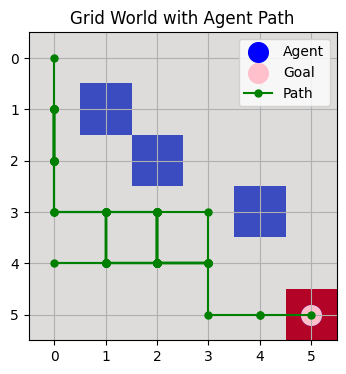

--- Episode 49 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (3, 0) with reward -1
Step 4: Moved from (3, 0) to (3, 1) with reward -1
Step 5: Moved from (3, 1) to (3, 2) with reward -1
Step 6: Moved from (3, 2) to (4, 2) with reward -1
Step 7: Moved from (4, 2) to (4, 3) with reward -1
Step 8: Moved from (4, 3) to (4, 2) with reward -1
Step 9: Moved from (4, 2) to (4, 1) with reward -1
Step 10: Moved from (4, 1) to (4, 2) with reward -1
Step 11: Moved from (4, 2) to (4, 1) with reward -1
Step 12: Moved from (4, 1) to (4, 2) with reward -1
Step 13: Moved from (4, 2) to (4, 3) with reward -1
Step 14: Moved from (4, 3) to (5, 3) with reward -1
Step 15: Moved from (5, 3) to (5, 4) with reward -1
Step 16: Moved from (5, 4) to (5, 5) with reward 100
Episode 49 complete, Total Steps: 16


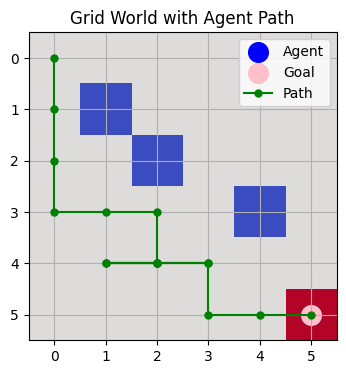

--- Episode 50 ---
Step 1: Moved from (0, 0) to (1, 0) with reward -1
Step 2: Moved from (1, 0) to (2, 0) with reward -1
Step 3: Moved from (2, 0) to (1, 0) with reward -1
Step 4: Moved from (1, 0) to (2, 0) with reward -1
Step 5: Moved from (2, 0) to (1, 0) with reward -1
Step 6: Moved from (1, 0) to (2, 0) with reward -1
Step 7: Moved from (2, 0) to (2, 1) with reward -1
Step 8: Moved from (2, 1) to (2, 1) with reward -10
Step 9: Moved from (2, 1) to (2, 1) with reward -10
Step 10: Moved from (2, 1) to (2, 1) with reward -10
Step 11: Moved from (2, 1) to (2, 1) with reward -10
Step 12: Moved from (2, 1) to (2, 1) with reward -10
Step 13: Moved from (2, 1) to (3, 1) with reward -1
Step 14: Moved from (3, 1) to (3, 2) with reward -1
Step 15: Moved from (3, 2) to (3, 3) with reward -1
Step 16: Moved from (3, 3) to (3, 3) with reward -10
Step 17: Moved from (3, 3) to (3, 3) with reward -10
Step 18: Moved from (3, 3) to (4, 3) with reward -1
Step 19: Moved from (4, 3) to (4, 4) with rewar

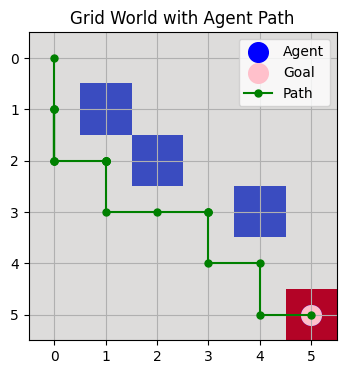


Q-learning complete.

Average Steps per Episode: 190.24


In [48]:
# Define the Q-learning algorithm with a neural network and visualization
def q_learning(episodes=50, max_steps=200):
    """Performs Q-learning with neural network updates and visualizes each episode's path.

    Args:
        episodes (int): Number of episodes for training.
        max_steps (int): Maximum steps allowed per episode.

    Returns:
        tuple: Lists of steps per episode and paths taken in each episode.
    """
    print(f"Starting Q-learning for {episodes} episodes...\n")

    # Initialize metrics and storage for paths
    all_paths = []  # Tracks paths per episode

    for episode in range(episodes):
        state = start_state       # Reset agent to start state at the beginning of each episode
        steps = 0                 # Step counter for the current episode
        agent_path = [state]      # Record the agent's path

        print(f"--- Episode {episode + 1} ---")

        # Episode loop
        while state != goal_state and steps < max_steps:
            action = choose_action(state)  # Choose action based on epsilon-greedy policy
            next_state = tuple(np.add(state, action_map[actions[action]]))  # Calculate the next state

            # Check if the move is valid (within grid bounds and not an obstacle)
            if (next_state[0] < 0 or next_state[0] >= grid_height or
                next_state[1] < 0 or next_state[1] >= grid_width or
                next_state in obstacles):
                reward = -10       # Penalty for invalid move (hitting obstacle or boundary)
                next_state = state  # Stay in the current state
            elif next_state == goal_state:
                reward = 100       # Reward for reaching the goal
            else:
                reward = -1        # Small penalty for each step to encourage shorter paths

            # Store experience in replay buffer
            replay_buffer.append((state, action, reward, next_state))

            # Train the network if enough samples are available in replay buffer
            if len(replay_buffer) >= batch_size:
                # Sample a batch and unpack the experiences
                batch = random.sample(replay_buffer, batch_size)
                state_batch, action_batch, reward_batch, next_state_batch = zip(*batch)

                # Convert batch data to tensors
                state_batch = torch.tensor(state_batch, dtype=torch.float32)
                action_batch = torch.tensor(action_batch, dtype=torch.long)
                reward_batch = torch.tensor(reward_batch, dtype=torch.float32)
                next_state_batch = torch.tensor(next_state_batch, dtype=torch.float32)

                # Current Q-values for chosen actions
                q_values = q_network(state_batch).gather(1, action_batch.unsqueeze(1)).squeeze()

                # Target Q-values for the next states
                with torch.no_grad():
                    max_next_q_values = q_network(next_state_batch).max(1)[0]
                target_q_values = reward_batch + gamma * max_next_q_values

                # Update the Q-network
                loss = loss_function(q_values, target_q_values)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Update state, path, and step count
            state = next_state
            agent_path.append(state)
            steps += 1
            print(f"Step {steps}: Moved from {agent_path[-2]} to {state} with reward {reward}")

        # Record metrics and path for the episode
        steps_per_episode.append(steps)
        all_paths.append(agent_path)

        # Episode completion log
        print(f"Episode {episode + 1} complete, Total Steps: {steps}")

        # Visualize the grid world and agent's path after each episode
        plot_grid_world(state, goal_state, obstacles, agent_path)

    print("\nQ-learning complete.")
    return steps_per_episode, all_paths

# Visualization function for grid world with agent's path
def plot_grid_world(agent_pos, goal_pos, obstacles, path):
    """Visualizes the grid world, agent's path, obstacles, and goal."""

    # Initialize grid with zeros, set goal and obstacles
    grid = np.zeros((grid_height, grid_width))
    grid[goal_pos] = 1  # Mark goal position
    for obs in obstacles:
        grid[obs] = -1  # Mark obstacles

    # Plot grid with a new color map, e.g., 'coolwarm', 'plasma', 'cividis'
    plt.figure(figsize=(6, 4))
    plt.imshow(grid, cmap='coolwarm', origin='upper')  # Change 'coolwarm' to any preferred colormap
    plt.scatter(agent_pos[1], agent_pos[0], color='blue', s=200, label='Agent')
    plt.scatter(goal_pos[1], goal_pos[0], color='pink', s=200, label='Goal')

    # Draw the agent's path on the grid
    if path:
        path_x, path_y = zip(*path)
        plt.plot(path_y, path_x, color='green', marker='o', markersize=5, label='Path')

    # Customize plot
    plt.xticks(range(grid_width))
    plt.yticks(range(grid_height))
    plt.grid()
    plt.legend()
    plt.title('Grid World with Agent Path')
    plt.show()

# Run the Q-learning algorithm
steps_per_episode, all_paths = q_learning(episodes=50)

# Output summary of results for evaluation
average_steps = np.mean(steps_per_episode)
print(f"\nAverage Steps per Episode: {average_steps:.2f}")


In [49]:
def plot_grid_world(agent_pos, goal_pos, obstacles, path):
    """Visualizes the grid world environment with the agent's path, obstacles, and goal.

    Args:
        agent_pos (tuple): Current position of the agent (row, col).
        goal_pos (tuple): Position of the goal in the grid (row, col).
        obstacles (list of tuples): List of positions for obstacles.
        path (list of tuples): Sequence of positions representing the agent's path.
    """

    # Initialize grid with zeros and mark goal and obstacles
    grid = np.zeros((grid_height, grid_width))
    grid[goal_pos] = 1  # Mark goal location in grid
    for obs in obstacles:
        grid[obs] = -1  # Mark obstacle locations

    # Set up the plot with a customized colormap
    plt.figure(figsize=(6, 4))
    plt.imshow(grid, cmap='coolwarm', origin='upper')  # Change 'coolwarm' to any other color map

    # Plot agent, goal, and path
    plt.scatter(agent_pos[1], agent_pos[0], color='blue', s=200, label='Agent')  # Agent position
    plt.scatter(goal_pos[1], goal_pos[0], color='gold', s=200, label='Goal')     # Goal position

    # Draw agent's path
    if path:
        path_x, path_y = zip(*path)
        plt.plot(path_y, path_x, color='orange', marker='o', markersize=5, label='Path')

    # Customize the plot appearance
    plt.xticks(range(grid_width))
    plt.yticks(range(grid_height))
    plt.grid(visible=True, color="gray", linestyle="--", linewidth=0.5)
    plt.legend()
    plt.title('Grid World with Agent Path')
    plt.show()

In [50]:
def display_optimized_q_values():
    """Displays the optimized Q-values for each state in the grid along with the best action."""

    print("\nOptimized Q-values and best action for each state:")

    for row in range(grid_height):
        for col in range(grid_width):
            # Define the current state as a tensor
            state = torch.tensor([row, col], dtype=torch.float32)

            # Compute Q-values without gradient tracking
            with torch.no_grad():
                q_values = q_network(state).numpy()  # Get Q-values as a numpy array

            # Determine the best action based on Q-values
            best_action = actions[np.argmax(q_values)]

            # Display Q-values and best action for the current state
            print(f"State ({row}, {col}): Q-values = {q_values}, Best Action = '{best_action}'")

In [51]:
# Display optimized Q-values for each state after training
display_optimized_q_values()


Optimized Q-values and best action for each state:
State (0, 0): Q-values = [-16.647259   -4.7757783 -14.8735695 -15.309376 ], Best Action = 'down'
State (0, 1): Q-values = [-31.467535 -17.359837  -5.989962 -19.47351 ], Best Action = 'left'
State (0, 2): Q-values = [-35.676876  -19.423597   -2.0680628 -18.426567 ], Best Action = 'left'
State (0, 3): Q-values = [-38.950867  -21.074978    1.0365301 -17.317059 ], Best Action = 'left'
State (0, 4): Q-values = [-42.495205 -22.714676   3.509288 -16.368832], Best Action = 'left'
State (0, 5): Q-values = [-46.215992  -24.397654    5.7329016 -15.545795 ], Best Action = 'left'
State (1, 0): Q-values = [ -9.585825  -4.295892 -15.397619 -11.828104], Best Action = 'down'
State (1, 1): Q-values = [-17.414557  -6.523664  -7.484659 -11.835708], Best Action = 'down'
State (1, 2): Q-values = [-22.090315   -9.742942   -3.8308587 -11.244003 ], Best Action = 'left'
State (1, 3): Q-values = [-24.947327   -11.668446    -0.15681992  -9.571946  ], Best Action

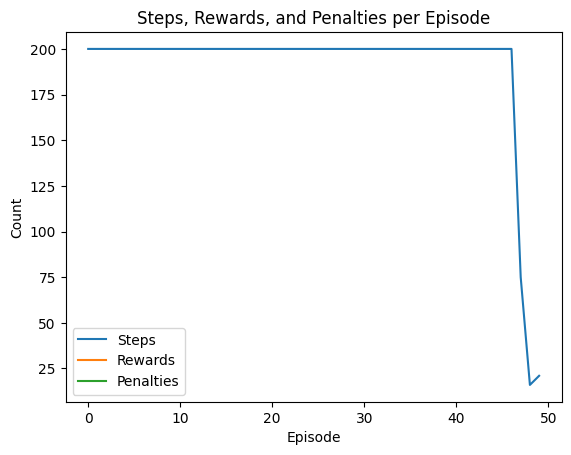

In [52]:
# Plot steps, rewards, and penalties per episode
plt.figure()
plt.plot(steps_per_episode, label="Steps")
plt.plot(rewards_per_episode, label="Rewards")
plt.plot(penalties_per_episode, label="Penalties")
plt.xlabel("Episode")
plt.ylabel("Count")
plt.title("Steps, Rewards, and Penalties per Episode")
plt.legend()
plt.show()

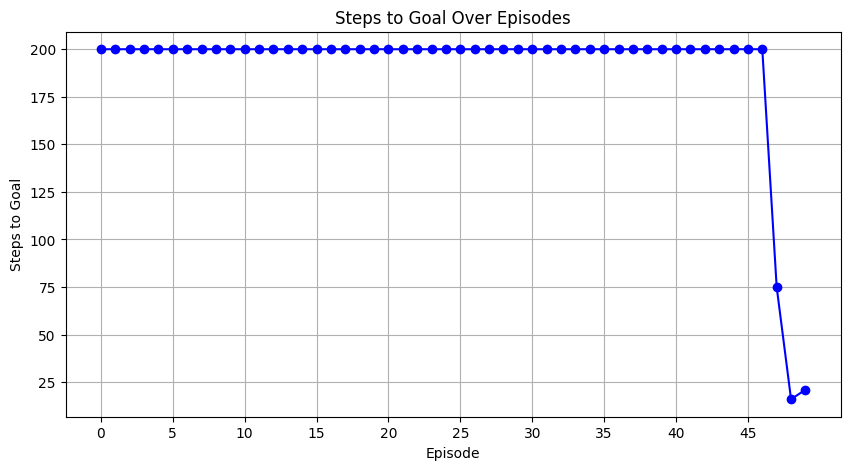

In [53]:
# Plot the steps-to-go curve
plt.figure(figsize=(10, 5))
plt.plot(steps_per_episode, marker='o', linestyle='-', color='b')
plt.xlabel('Episode')
plt.ylabel('Steps to Goal')
plt.title('Steps to Goal Over Episodes')
plt.xticks(range(0, episodes, 5))
plt.grid()
plt.show()